In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
import pyreadr
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, classification_report

from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier



In [2]:
archivo = '../Data/listings.RData'
data_raw = pyreadr.read_r(archivo)
data_airbnb = data_raw['listings'].copy()


In [3]:
print("Dataset shape")
print(data_airbnb.shape)
print()
print("Dataset vista")
display(data_airbnb.head() )

Dataset shape
(171748, 80)

Dataset vista


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.69,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas"
3,13035.0,https://www.airbnb.com/rooms/13035,2.025092e+13,2025-09-17,city scrape,Historic house in highly walkable East Austin,Comfortable 2 bedroom/2 bathroom home very cen...,East Cesar Chavez is a gentrifying urban area ...,https://a0.muscache.com/pictures/miso/Hosting-...,50793,...,5.00,4.95,NaN,f,2,2,0,0,0.11,"Austin, Texas"
4,22828.0,https://www.airbnb.com/rooms/22828,2.025092e+13,2025-09-16,city scrape,Garage Apartment central SE Austin,"Fully furnished, centrally located, second sto...","wikipedia: East_Riverside-Oltorf,_Austin,_Texas",https://a0.muscache.com/pictures/miso/Hosting-...,56488,...,4.72,4.84,NaN,f,1,1,0,0,0.30,"Austin, Texas"


In [4]:
data_airbnb['price_clean']= ( data_airbnb['price'] .astype(str) .str.replace(r'[$,]', '', regex=True)  .str.strip() )

data_airbnb['price_clean'] = pd.to_numeric(data_airbnb['price_clean'], errors='coerce')

data_airbnb = data_airbnb[  data_airbnb['price_clean'].notna() & (data_airbnb['price_clean'] > 0) ].copy()


print("shape limpia:", data_airbnb.shape)
print(data_airbnb['price_clean'].describe())

shape limpia: (76246, 81)
count    76246.000000
mean       750.509220
std       4250.606945
min          8.000000
25%        120.000000
50%        193.000000
75%        326.000000
max      50123.000000
Name: price_clean, dtype: float64


In [5]:
q1 = data_airbnb['price_clean'].quantile(0.25)
q3 =data_airbnb['price_clean'].quantile(0.75 )
iqr = q3 - q1

limite_superior= q3 + 1.5 * iqr

data_sin_outliers = data_airbnb[ data_airbnb['price_clean'] <= limite_superior ].copy()

print("shape sin outliers:", data_sin_outliers.shape)
print()
print(data_sin_outliers['price_clean'].describe())

shape sin outliers: (68737, 81)

count    68737.000000
mean       209.363458
std        128.664537
min          8.000000
25%        114.000000
50%        177.000000
75%        274.000000
max        635.000000
Name: price_clean, dtype: float64


In [6]:
features = [ 'accommodates',
    'bedrooms' ,
    'beds' ,
    'bathrooms',
    'number_of_reviews' ,
    'availability_365'
]

features = [f for f in features if f in data_sin_outliers.columns]

print("Features comunes:" , features )

Features comunes: ['accommodates', 'bedrooms', 'beds', 'bathrooms', 'number_of_reviews', 'availability_365']


In [7]:
X = data_sin_outliers[features].copy()
y_real = data_sin_outliers['price_clean'].copy()

print("Shape X:", X.shape )
print("Shape y:", y_real.shape )

Shape X: (68737, 6)
Shape y: (68737,)


In [8]:
imputer= SimpleImputer(strategy='mean')

X= pd.DataFrame( imputer.fit_transform(X), columns=features, index=X.index)

print(" nulos por columna después de imputar:")
print()
print(X.isnull().sum())

 nulos por columna después de imputar:

accommodates         0
bedrooms             0
beds                 0
bathrooms            0
number_of_reviews    0
availability_365     0
dtype: int64


c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_real, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (54989, 6)
Test: (13748, 6)


## 1. KNN

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
from sklearn.neighbors import KNeighborsRegressor

knn_reg = KNeighborsRegressor(n_neighbors=5)

knn_reg.fit(X_train_scaled, y_train)

y_pred = knn_reg.predict(X_test_scaled)

In [12]:
import pandas as pd

resultados = pd.DataFrame({
    "Real": y_test,
    "Predicho": y_pred
})

resultados.head()

,Real,Predicho
12326,233.0,208.8
15538,89.0,119.6
28975,225.0,151.0
24444,249.0,96.4
24598,289.0,310.4


## 2.Evaluacion del Modelo

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 79.09918533604888
RMSE: 106.86544701123586


## 4 KNN Clasificacion

In [14]:
def categorizar_precio(x):
    if x < 100:
        return "barata"
    elif x < 200:
        return "media"
    else:
        return "cara"

y_cat = y_real.apply(categorizar_precio)

y_cat.value_counts()

price_clean
cara      29175
media     26677
barata    12885
Name: count, dtype: int64

In [15]:
from sklearn.model_selection import train_test_split

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_cat, test_size=0.2, random_state=42
)

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_c = scaler.fit_transform(X_train_c)
X_test_c = scaler.transform(X_test_c)

In [17]:
from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier(n_neighbors=5)

knn_clf.fit(X_train_c, y_train_c)

y_pred_c = knn_clf.predict(X_test_c)

In [18]:
import pandas as pd

resultados_clf = pd.DataFrame({
    "Real": y_test_c,
    "Predicho": y_pred_c
})

resultados_clf.head()

,Real,Predicho
12326,cara,cara
15538,barata,media
28975,cara,barata
24444,cara,barata
24598,cara,cara


## Evaluar Clasificacion

In [19]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test_c, y_pred_c)

print("Accuracy:", accuracy)

Accuracy: 0.5721559499563573


In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test_c, y_pred_c))

              precision    recall  f1-score   support

      barata       0.48      0.51      0.50      2559
        cara       0.64      0.69      0.67      5843
       media       0.53      0.47      0.50      5346

    accuracy                           0.57     13748
   macro avg       0.55      0.56      0.55     13748
weighted avg       0.57      0.57      0.57     13748



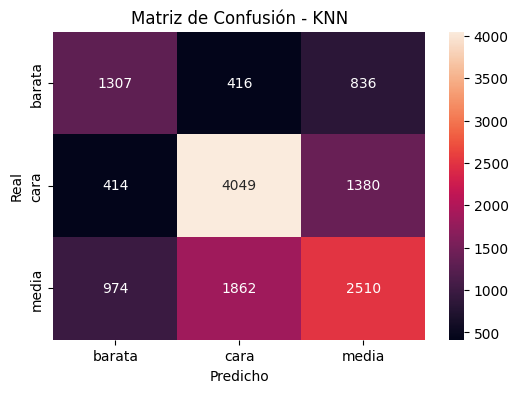

In [21]:
cm = confusion_matrix(y_test_c, y_pred_c)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['barata','cara','media'],
            yticklabels=['barata','cara','media'])

plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión - KNN')
plt.show()

## Overfitting

In [ ]:
y_train_pred = knn_clf.predict(X_train_c)

train_accuracy = accuracy_score(y_train_c, y_train_pred)

print("Accuracy TRAIN:", train_accuracy)
print("Accuracy TEST:", accuracy)

Accuracy TRAIN: 0.6974667660804889
Accuracy TEST: 0.5721559499563573


## Validación Cruzada

In [ ]:
cv_scores = cross_val_score(knn_clf, X_train_c, y_train_c, cv=5, scoring='accuracy')

print("Accuracy por fold:", cv_scores)
print("Accuracy promedio:", cv_scores.mean())

Accuracy por fold: [0.56264775 0.56437534 0.56019276 0.56337516 0.56597254]
Accuracy promedio: 0.5633127109026727


## Tuneo de Hiperparámetros (KNN)


In [27]:
param_grid = {
    'n_neighbors': [3,5,7,9,11],
    'weights': ['uniform','distance'],
    'p': [1,2]  # 1 = manhattan, 2 = euclidiana
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')

grid.fit(X_train_c, y_train_c)

print("Mejores parámetros:", grid.best_params_)
print("Mejor accuracy (cv):", grid.best_score_)

Mejores parámetros: {'n_neighbors': 11, 'p': 2, 'weights': 'uniform'}
Mejor accuracy (cv): 0.5863536622586963


## Evaluación del Modelo Tuneado

In [28]:
best_knn = grid.best_estimator_

y_pred_best = best_knn.predict(X_test_c)


accuracy_best = accuracy_score(y_test_c, y_pred_best)

print("Accuracy modelo original:", accuracy)
print("Accuracy modelo tuneado:", accuracy_best)

Accuracy modelo original: 0.5721559499563573
Accuracy modelo tuneado: 0.5910677916787896


## Matriz de Confusión

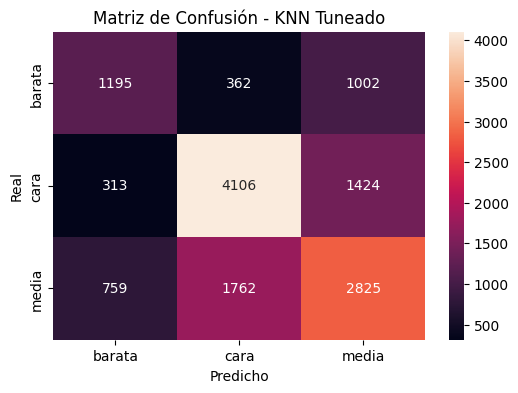

In [29]:
cm_best = confusion_matrix(y_test_c, y_pred_best)

plt.figure(figsize=(6,4))
sns.heatmap(cm_best, annot=True, fmt='d',
            xticklabels=['barata','cara','media'],
            yticklabels=['barata','cara','media'])

plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión - KNN Tuneado')
plt.show()

## Comparación de Modelos de Clasificación

In [36]:
accuracy_tree = 0.5253  
accuracy_rf =  0.5752
accuracy_nb = 0.5185

print("Árbol de decisión:", accuracy_tree)
print("Random Forest:", accuracy_rf)
print("Naive Bayes:", accuracy_nb)
print("KNN:", accuracy_best)

Árbol de decisión: 0.5253
Random Forest: 0.5752
Naive Bayes: 0.5185
KNN: 0.5910677916787896
